# Абляционный анализ групп признаков

Ноутбук отвечает на вопрос научного руководителя: что даёт каждая группа признаков,
если обучать **одну и ту же модель**, последовательно добавляя всё более богатые блоки —
сначала только лаг зависимости, затем признаки из истории зависимости, затем доходности
биткоина, затем признаки связанного актива, и в конце полная модель.

Важно понимать, чем это отличается от важностей признаков. Важности показывают, как
**уже обученная** модель распределила вес между входами. Они не отвечают на вопрос, чего
модель достигла бы **без** какой-то группы входов. Здесь модель переобучается заново на
каждом наборе, поэтому разница в ошибке между строками — это и есть вклад добавленного блока.

Данные берутся замороженные, те же, что в работе: ничего не скачивается и не пересчитывается
заново, результаты диплома этим ноутбуком не затрагиваются.


## Настройка


In [1]:
import os, sys, warnings

# sklearn при параллельном обучении печатает предупреждение на каждый вызов;
# на 2961 шаге walk-forward это сотни тысяч строк, которые раздувают ноутбук
warnings.filterwarnings('ignore')

# ищем корень репозитория, чтобы ноутбук запускался и из notebooks/, и из корня
ROOT = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(ROOT, 'config.yaml')):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError('не нашёл config.yaml — запустите из репозитория')
    ROOT = parent
sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from thesis_app.pipeline import build_features, build_target, fit_predict_walk_forward
from thesis_app.notebook_helpers import apply_thesis_plot_style

apply_thesis_plot_style()
plt.rcParams['axes.titleweight'] = 'bold'

CFG = yaml.safe_load(open(os.path.join(ROOT, 'config.yaml'), encoding='utf-8'))
print('корень репозитория:', ROOT)


корень репозитория: D:\clear


In [2]:
# pipeline.py при импорте переключает matplotlib на Agg (файловый бэкенд),
# поэтому графики в ноутбуке не отображались бы; возвращаем встроенный
%matplotlib inline


## Данные и цель

Репрезентативная пара — Bitcoin против S&P 500, окно скользящей корреляции 30 дней.
Цель — та же, что в работе: скользящая корреляция Пирсона, преобразованная по Фишеру,
прогноз на один день вперёд.


In [3]:
BASE, OTHER, WINDOW = 'BTC-USD', '^GSPC', 30

returns = pd.read_csv(os.path.join(ROOT, 'data', 'processed', 'returns.csv'),
                      index_col=0, parse_dates=True)

use_fisher = bool(CFG.get('use_fisher_transform', True))
horizon = int(CFG.get('forecast_horizon', 1))

y = build_target(returns, BASE, OTHER, WINDOW, horizon, use_fisher)
X_full = build_features(returns, WINDOW, y, BASE, OTHER, horizon)
y_aligned = y.loc[X_full.index]

print(f'период: {X_full.index.min().date()} — {X_full.index.max().date()}')
print(f'наблюдений после выравнивания: {len(X_full)}')
print(f'признаков в полной матрице: {X_full.shape[1]}')


период: 2018-02-11 — 2026-05-15
наблюдений после выравнивания: 2961
признаков в полной матрице: 32


## Группы признаков

Пять наборов, каждый следующий **содержит предыдущий целиком**. Вложенность здесь
принципиальна: только при ней разницу между строками можно читать как вклад именно
добавленного блока, а не как результат подмены набора.

Группы собираются фильтрами по именам столбцов, а не списком вручную, и в конце стоит
проверка полноты: если в пайплайн добавят новый признак и забудут отнести его к группе,
ячейка упадёт, а не посчитает молча неполную абляцию.


In [4]:
def feature_groups(columns):
    """Вложенные наборы признаков в порядке усложнения модели."""
    dep_lag1 = ['dep_lag1']
    dep_history = [c for c in columns if c.startswith('dep_')] + \
                  [c for c in columns if c.startswith('corr_')]
    base_block = [c for c in columns
                  if c.startswith('r_base_') or c in {'vol_base', 'vol_base_60', 'mean_base'}]
    other_block = [c for c in columns
                   if c.startswith('r_other_') or c in {'vol_other', 'vol_other_60', 'mean_other'}]
    interaction = [c for c in columns if c in {'vol_ratio', 'abs_spread', 'abs_spread_20'}]

    g1 = dep_lag1
    g2 = sorted(set(g1) | set(dep_history))
    g3 = sorted(set(g2) | set(base_block))
    g4 = sorted(set(g3) | set(other_block))
    g5 = sorted(set(g4) | set(interaction))

    missing = sorted(set(columns) - set(g5))
    if missing:
        raise AssertionError(f'признаки не распределены по группам: {missing}')

    return {
        'G1 только лаг зависимости':        g1,
        'G2 + история зависимости':         g2,
        'G3 + доходности Bitcoin':          g3,
        'G4 + признаки связанного актива':  g4,
        'G5 полная модель':                 g5,
    }

groups = feature_groups(list(X_full.columns))

prev = set()
for name, cols in groups.items():
    added = sorted(set(cols) - prev)
    print(f'\n{name}  —  всего {len(cols)}, добавлено {len(added)}')
    print('   ' + ', '.join(added))
    prev = set(cols)



G1 только лаг зависимости  —  всего 1, добавлено 1
   dep_lag1

G2 + история зависимости  —  всего 11, добавлено 10
   corr_diff, corr_short_mom, dep_lag10, dep_lag2, dep_lag20, dep_lag5, dep_lag60, dep_mom_20, dep_mom_5, dep_zscore

G3 + доходности Bitcoin  —  всего 20, добавлено 9
   mean_base, r_base_lag1, r_base_lag10, r_base_lag2, r_base_lag20, r_base_lag5, r_base_sq_lag1, vol_base, vol_base_60

G4 + признаки связанного актива  —  всего 29, добавлено 9
   mean_other, r_other_lag1, r_other_lag10, r_other_lag2, r_other_lag20, r_other_lag5, r_other_sq_lag1, vol_other, vol_other_60

G5 полная модель  —  всего 32, добавлено 3
   abs_spread, abs_spread_20, vol_ratio


## Прогон

Отдельной процедуры обучения здесь нет — вызывается **та же** функция, что и в основном
эксперименте работы. Расширяющееся окно, `min_train = 800`, переобучение каждые 20 шагов,
сид 42; всё берётся из `config.yaml`, а не задаётся заново. Между прогонами меняется
ровно один аргумент — срез столбцов `X_full[cols]`.

Считаем по трём моделям: Ridge, Random Forest и XGBoost. Одной было бы мало — весь смысл
результата в том, что линейная модель и деревья ведут себя противоположно.

Прогон занимает порядка 15–25 минут.


In [5]:
REPORTED = {'Ridge': 'Ridge', 'RF': 'Random Forest',
            'XGB_GPU': 'XGBoost', 'XGB_CPU': 'XGBoost'}

rows = []
for name, cols in groups.items():
    print(f'[{name}]  {len(cols)} признаков ... ', end='', flush=True)
    _, metrics = fit_predict_walk_forward(
        X=X_full[cols],
        y=y_aligned,
        min_train=int(CFG['min_train_size']),
        refit_every=int(CFG['refit_every']),
        random_state=int(CFG['random_state']),
        use_xgb=True,
        xgb_device=str(CFG.get('xgb_device', 'cuda')),
    )
    row = {'Набор': name, 'Признаков': len(cols)}
    for _, m in metrics.iterrows():
        label = REPORTED.get(m['model'])
        if label:
            row[f'{label} RMSE'] = m['RMSE']
            row[f'{label} R2'] = m['R2']
    rows.append(row)
    print('готово')

abl = pd.DataFrame(rows)
abl


[G1 только лаг зависимости]  1 признаков ... 

готово
[G2 + история зависимости]  11 признаков ... 

готово
[G3 + доходности Bitcoin]  20 признаков ... 

готово
[G4 + признаки связанного актива]  29 признаков ... 

готово
[G5 полная модель]  32 признаков ... 

готово


,Набор,Признаков,Ridge RMSE,Ridge R2,XGBoost RMSE,XGBoost R2,Random Forest RMSE,Random Forest R2
0,G1 только лаг зависимости,1,0.089861,0.884939,0.098028,0.863075,0.098649,0.861335
1,G2 + история зависимости,11,0.064914,0.939957,0.103001,0.848828,0.088434,0.888564
2,G3 + доходности Bitcoin,20,0.064924,0.939939,0.105756,0.840633,0.089149,0.886755
3,G4 + признаки связанного актива,29,0.065027,0.939748,0.107781,0.834472,0.090193,0.884086
4,G5 полная модель,32,0.065073,0.939663,0.113438,0.816642,0.090958,0.882113


## Результаты

Ниже — та же таблица, но с приростом относительно предыдущей строки. Отрицательное
значение означает уменьшение ошибки, то есть пользу от добавленного блока.


In [6]:
models = ['Ridge', 'Random Forest', 'XGBoost']

delta = abl[['Набор', 'Признаков']].copy()
for m in models:
    delta[f'{m} RMSE'] = abl[f'{m} RMSE'].round(4)
    delta[f'{m} Δ'] = abl[f'{m} RMSE'].diff().round(4)

delta.style.format(na_rep='—').background_gradient(
    subset=[f'{m} Δ' for m in models], cmap='RdYlGn_r')


,Набор,Признаков,Ridge RMSE,Ridge Δ,Random Forest RMSE,Random Forest Δ,XGBoost RMSE,XGBoost Δ
0,G1 только лаг зависимости,1,0.089900,—,0.098600,—,0.098000,—
1,G2 + история зависимости,11,0.064900,-0.024900,0.088400,-0.010200,0.103000,0.005000
2,G3 + доходности Bitcoin,20,0.064900,0.000000,0.089100,0.000700,0.105800,0.002800
3,G4 + признаки связанного актива,29,0.065000,0.000100,0.090200,0.001000,0.107800,0.002000
4,G5 полная модель,32,0.065100,0.000000,0.091000,0.000800,0.113400,0.005700


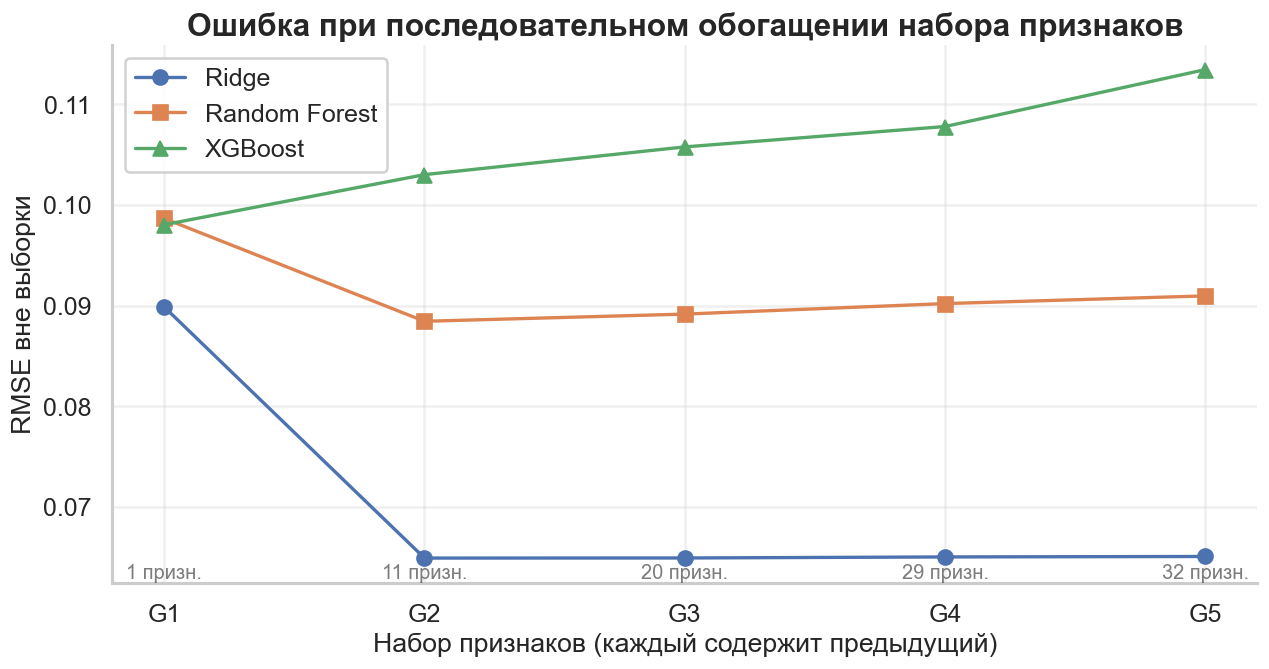

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(abl))
for m, marker in zip(models, ['o', 's', '^']):
    ax.plot(x, abl[f'{m} RMSE'], marker=marker, lw=2, ms=9, label=m)

ax.set_xticks(x)
ax.set_xticklabels([n.split(' ', 1)[0] for n in abl['Набор']])
ax.set_xlabel('Набор признаков (каждый содержит предыдущий)')
ax.set_ylabel('RMSE вне выборки')
ax.set_title('Ошибка при последовательном обогащении набора признаков')
ax.legend()
ax.grid(True, alpha=0.3)

for i, n in enumerate(abl['Признаков']):
    ax.annotate(f'{n} призн.', (i, ax.get_ylim()[0]), ha='center', va='bottom',
                fontsize=12, alpha=0.6)

fig.tight_layout()
plt.show()


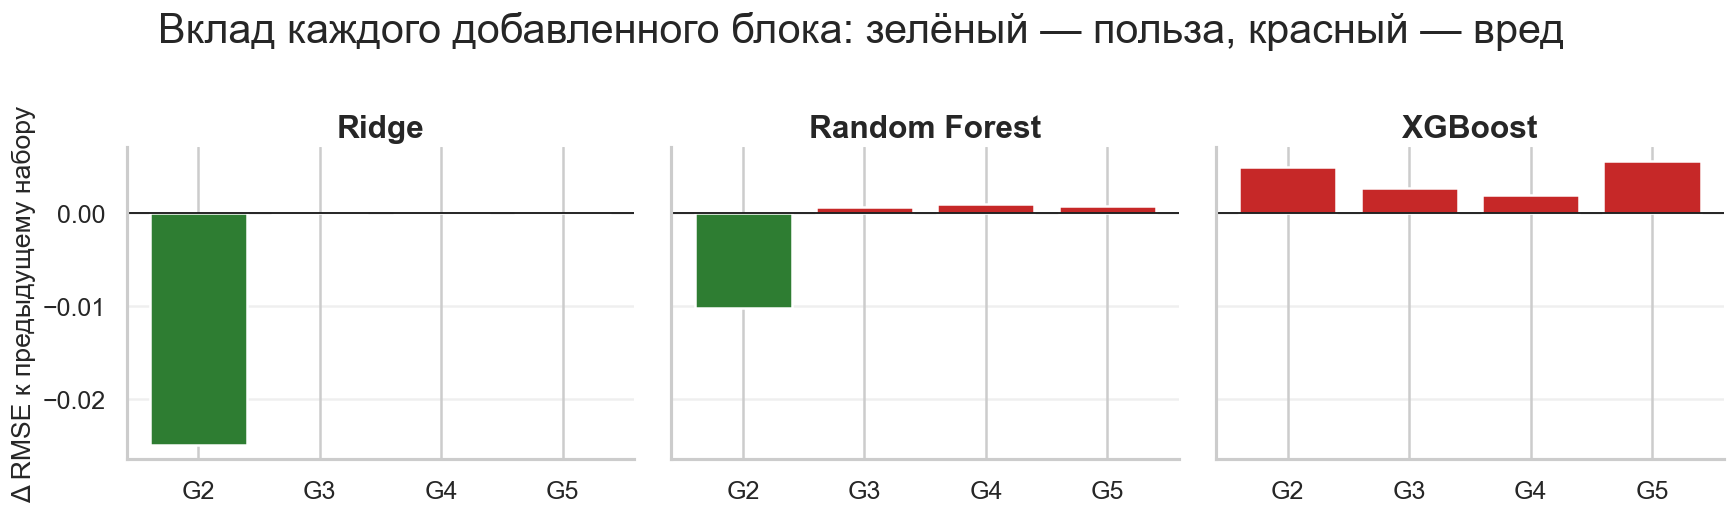

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, m in zip(axes, models):
    d = abl[f'{m} RMSE'].diff().iloc[1:]
    colors = ['#2e7d32' if v < 0 else '#c62828' for v in d]
    ax.bar(range(len(d)), d, color=colors)
    ax.axhline(0, color='black', lw=1)
    ax.set_xticks(range(len(d)))
    ax.set_xticklabels(['G2', 'G3', 'G4', 'G5'])
    ax.set_title(m)
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('Δ RMSE к предыдущему набору')
fig.suptitle('Вклад каждого добавленного блока: зелёный — польза, красный — вред')
fig.tight_layout()
plt.show()


## Выводы

**Одного лага уже почти достаточно.** Ridge на единственном столбце `dep_lag1` даёт
$R^2 \approx 0.885$. Никакой кросс-активной информации при этом нет вообще.

**Помогает только история самой зависимости.** Переход G1 → G2 даёт Ridge заметное
улучшение, после чего наступает плато: доходности биткоина, признаки S&P 500 и
кросс-активные признаки не меняют ошибку в четвёртом знаке. То есть примерно две трети
матрицы признаков не зарабатывают ничего.

**Деревьям лишние признаки вредят, причём монотонно.** XGBoost показывает лучший
результат на одном лаге и ухудшается на каждом следующем шаге. Объяснение простое:
каждый новый блок расширяет пространство разбиений, доступное ансамблю, а сигнала о цели
в этих столбцах нет — значит, дополнительная свобода тратится на подгонку под шум
обучающего окна. Ridge то же самое просто зануляет регуляризацией.

Это же объясняет то, что в основной таблице работы выглядит странно: деревья проигрывают
линейным моделям не потому, что не подходят задаче, а потому, что им дают предикторы,
которые безопасно проигнорировать умеет только сильная регуляризация.
